# CIFAR-10 Image Classification

## 1 Introduction#

### 1.1 Overview

In the realm of artificial intelligence and computer vision, image classification stands as a foundational task with wide-ranging applications. One such pivotal benchmark dataset that has fueled the advancement of image classification algorithms is the CIFAR-10 dataset. Comprising 60,000 32x32 color images across 10 distinct classes, CIFAR-10 presents a challenging scenario for machine learning models due to its small image size, varied classes, and complex variations within each class. This project aims to harness the power of machine learning to tackle the CIFAR-10 classification problem, leveraging cutting-edge techniques to discern and label images with remarkable accuracy.

### 1.2 Problem Defintion

The primary objective of this project is to build an image classification model that can accurately assign one of ten predefined labels to each image in the CIFAR-10 dataset. The dataset contains images across the following classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck. The challenge herein lies in training a model that can generalize its learning from a limited set of small images to correctly classify unseen images with a high level of accuracy.

The key problem components include:

1. **Small Image Size:** The CIFAR-10 images are only 32x32 pixels in size, resulting in a substantial loss of fine-grained details. This scarcity of information necessitates the development of feature extraction techniques that can effectively capture the discriminative characteristics of each class.

2. **Variability within Classes:** The classes in CIFAR-10 are diverse, encompassing animals, vehicles, and objects. However, even within each class, there exists considerable intra-class variability due to different angles, poses, lighting conditions, and backgrounds. Addressing this variability demands a model that can identify core characteristics while ignoring less relevant variations.

3. **Limited Dataset Size:** With a total of 60,000 images divided into 10 classes, the dataset is relatively small compared to modern deep learning standards. This scarcity of data necessitates the exploration of techniques such as data augmentation, transfer learning, and regularization to prevent overfitting and promote generalization.

4. **Model Complexity:** Achieving high accuracy on CIFAR-10 necessitates the development of complex models capable of learning intricate patterns and relationships. Balancing model complexity with computational resources and training time presents a critical trade-off that needs to be addressed.

5. **Evaluation Metric:** The success of the image classification model will be evaluated primarily based on its accuracy in correctly classifying images from the test dataset. However, other metrics like precision, recall, and F1-score can provide additional insights into the model's performance across different classes.

This project embarks on the journey of unraveling the CIFAR-10 classification challenge. By harnessing state-of-the-art machine learning techniques, it aims to push the boundaries of image classification, advancing our understanding of model architectures, feature extraction, and generalization strategies. Through this endeavor, the project endeavors to contribute to the growing landscape of AI-driven image analysis and classification.

### 1.3 Defining our Measure of Success

The measure of success for this project will primarily revolve around the accuracy achieved by the image classification model on the CIFAR-10 dataset. Accuracy is defined as the ratio of correctly classified images to the total number of images in the test dataset. However, considering the nuances of the CIFAR-10 dataset and the intricacies of image classification, it's important to consider additional evaluation metrics to provide a comprehensive view of the model's performance. Some of these metrics include:

1. **Accuracy:** This is the primary metric and represents the percentage of correctly classified images in the test dataset. It's a quick and intuitive measure of the model's performance.

2. **Precision:** Precision is the ratio of true positive predictions to the total number of positive predictions made by the model. It indicates how well the model avoids false positives. Precision is especially important when the cost of false positives is high.

3. **Recall (Sensitivity):** Recall is the ratio of true positive predictions to the total number of actual positives in the dataset. It measures the model's ability to correctly identify positive instances, avoiding false negatives. Recall is crucial when the cost of false negatives is high.

4. **F1-Score:** The F1-score is the harmonic mean of precision and recall. It provides a balanced view of a model's performance, especially when there's an uneven class distribution or when false positives and false negatives have different implications.

5. **Confusion Matrix:** A confusion matrix provides a detailed breakdown of the model's predictions and the actual class labels. It's useful for analyzing which classes the model tends to confuse and where the errors are occurring.

6. **Class-wise Metrics:** Since CIFAR-10 has multiple classes, evaluating performance on a per-class basis is insightful. It helps identify specific classes where the model excels and where it struggles.

7. **Training and Validation Curves:** Monitoring the training and validation curves for metrics like loss and accuracy can reveal information about the model's learning process. Sudden divergence or convergence can indicate issues such as overfitting or underfitting.

8. **Visualization of Misclassifications:** Visualizing the images that the model misclassifies can provide insights into the kinds of challenges it faces and the potential limitations of the chosen architecture and approach.

Ultimately, the measure of success for this project should encompass a combination of these metrics. The goal is to achieve a high accuracy while also maintaining good precision and recall, particularly in classes where accuracy is crucial. Balancing these metrics will demonstrate the model's ability to not only predict classes accurately but also to generalize well to unseen data and handle the challenges posed by the CIFAR-10 dataset.

## 2 Project Setup

### 2.1 Package Setup

In [1]:
try:
    import tensorflow as tf
    import numpy as np
    import matplotlib.pyplot as plt

    from tensorflow import keras
    from tensorflow.keras.datasets import cifar10

    print(f"Tensorflow version: {tf.__version__}")
except:
    !pip install tensorflow
    !pip install tensorflow-metal
    !pip install matplotlib
    
    import tensorflow as tf
    import numpy as np
    import matplotlib.pyplot as plt

    from tensorflow import keras
    
    print(f"Tensorflow version: {tf.__version__}")

Tensorflow version: 2.13.0


### 2.2 Download Dataset

In [2]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

170498071/170498071 [==============================] - 14s 0us/step


## 3 Data Exploration

Data exploration is a critical initial step in any machine learning project, including image classification tasks on datasets like CIFAR-10. It involves analyzing and understanding the dataset's characteristics, distribution, patterns, and potential challenges before diving into model building and training. Exploring the CIFAR-10 dataset serves several important purposes:

1. **Understanding Data Distribution:** Data exploration allows us to grasp the distribution of different classes within the dataset. In the case of CIFAR-10, understanding how many images belong to each of the ten classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck) is crucial. An imbalanced distribution could affect model training and evaluation.

2. **Identifying Data Anomalies:** Exploring the dataset helps uncover anomalies, outliers, or incorrectly labeled data points. These anomalies could impact model training and lead to unexpected results. Detecting and addressing these issues early can improve the model's performance.

3. **Feature Analysis:** Examining individual images in the dataset can provide insights into the features that distinguish different classes. This can guide preprocessing steps and influence the choice of image augmentation techniques.

4. **Data Preprocessing Strategy:** Exploring the data helps in determining what kind of preprocessing is necessary. For example, analyzing the distribution of pixel values could indicate whether normalization is needed. Understanding image dimensions can also guide decisions regarding resizing and cropping.

5. **Visualizing Data:** Visualization tools allow us to create plots and images that help you intuitively understand the dataset. Visualizing a few sample images from each class can give you a sense of the complexity of the dataset and any potential challenges.

6. **Handling Imbalance:** If certain classes have significantly fewer examples than others, this imbalance can affect the model's ability to generalize. Data exploration can guide decisions about oversampling, undersampling, or using specialized techniques like focal loss.

7. **Selecting Relevant Features:** While in the context of images, the term "features" often refers to visual characteristics, exploratory analysis could reveal other features associated with the data, such as metadata or labels. These could be leveraged to enhance classification performance.

8. **Data Augmentation Strategy:** By understanding the variety of images within each class, we can tailor data augmentation strategies to better simulate real-world variations and challenges that the model might encounter.

9. **Choosing Model Complexity:** Insights gained from data exploration can influence decisions about the complexity of the model architecture. Understanding the dataset's intricacies helps strike a balance between model complexity and the dataset's characteristics.

In essence, data exploration empowers us to make informed decisions throughout the machine learning pipeline. It lays the foundation for effective data preprocessing, model selection, training, and evaluation. By investing time in understanding the dataset thoroughly, we can enhance the overall success of your image classification project on the CIFAR-10 dataset.

#### Understanding the Shape of the Dataset

Printing the shape of the training data and training labels is an essential step in data exploration and understanding the structure of your dataset before proceeding with any data processing or model training.

In [8]:
# Print the shape of the dataset
print("Training data shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Testing data shape:", test_images.shape)
print("Testing labels shape:", test_labels.shape)

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


`Training Data Shape: (50000, 32, 32, 3)`:
This indicates that the training dataset contains 50,000 samples (individual images).
Each image has a height of 32 pixels and a width of 32 pixels.
The number 3 indicates that each pixel is represented by three values, which correspond to the color channels Red, Green, and Blue (RGB).

`Training Labels Shape: (50000, 1)`:
This indicates that there are 50,000 labels associated with the training data.
Each label is represented as a single value.
The label value corresponds to the class index that the image belongs to. Class indices range from 0 to 9, representing the 10 different classes in the CIFAR-10 dataset.

#### Understanding Statistics of the Dataset

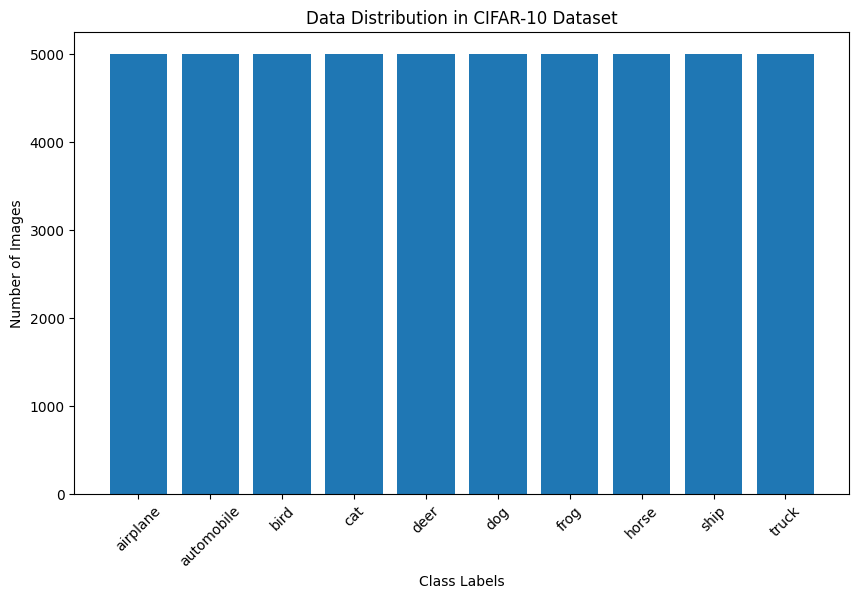

In [10]:
# Calculate the class distribution
class_counts = np.bincount(train_labels.flatten())
class_labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# Plot the data distribution
plt.figure(figsize=(10, 6))
plt.bar(class_labels, class_counts)
plt.title("Data Distribution in CIFAR-10 Dataset")
plt.xlabel("Class Labels")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

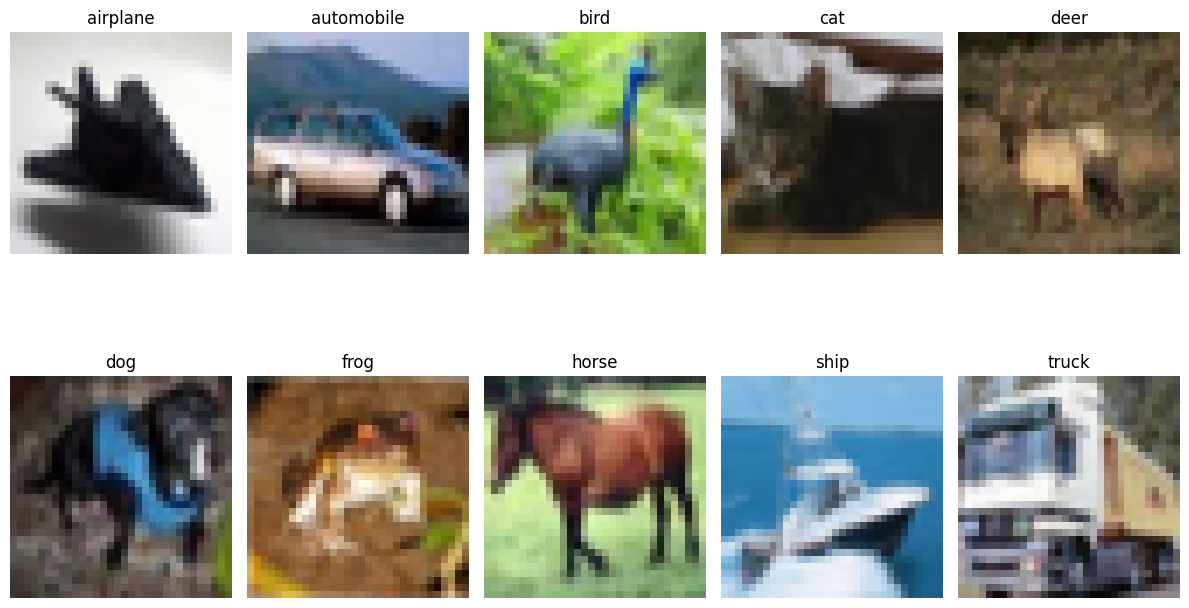

In [15]:
# Create a dictionary to store one image from each class
one_image_per_class = {}

# Loop through each class and find the first image belonging to that class
for class_idx, class_label in enumerate(class_labels):
    class_indices = np.where(train_labels == class_idx)[0]
    image_index = class_indices[0]
    one_image_per_class[class_label] = train_images[image_index]

# Display one image from each class
plt.figure(figsize=(12, 8))
for i, (class_label, image) in enumerate(one_image_per_class.items(), start=1):
    plt.subplot(2, 5, i)
    plt.imshow(image)
    plt.title(class_label)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 4 Data Proprocessing

Data preprocessing is a crucial step in preparing raw data for training machine learning and deep learning models. It involves a series of tasks aimed at cleaning, transforming, and structuring the data in a way that makes it suitable for model training. Data preprocessing not only improves model performance but also helps in avoiding common pitfalls and challenges that arise during the modeling process. Here's an overview of the key steps involved in data preprocessing:

1. **Data Cleaning:**
   - Handle missing values by imputing or removing them based on the nature of the data and the problem at hand.
   - Detect and handle outliers that might adversely affect the model's performance or lead to bias.

2. **Data Transformation:**
   - Normalize or scale numerical features to bring them to a common scale. This ensures that no feature dominates others due to its magnitude.
   - Encode categorical variables using techniques such as one-hot encoding or label encoding to enable the model to process them effectively.
   - Perform feature engineering, creating new features or transforming existing ones to capture more relevant information.

3. **Data Augmentation:**
   - In image-related tasks, apply data augmentation techniques to generate new training examples by applying random transformations like rotation, flipping, zooming, etc. This increases the effective size of the training dataset and improves model generalization.

4. **Feature Selection:**
   - Identify and select the most relevant features for model training. Removing irrelevant or redundant features can improve model efficiency and interpretability.

5. **Handling Imbalance:**
   - Address class imbalance by oversampling the minority class, undersampling the majority class, or using techniques like Synthetic Minority Over-sampling Technique (SMOTE).

6. **Data Normalization:**
   - Normalize the data to ensure that the input features have zero mean and unit variance. This can help accelerate model convergence during training.

Data preprocessing is a dynamic process that adapts to the specific characteristics of the dataset and the requirements of the problem. A well-executed preprocessing pipeline can significantly enhance the effectiveness of your machine learning models, leading to better generalization, improved model stability, and ultimately higher performance on real-world data.

## 5 Model Selection

## 6 Model Fine Tuning

## 7 Transfer Learning

## 8 Conclusion